In [1]:
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd 
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence


In [2]:


'''
Data loader for CatBoost. 
The data will be loaded so each object is in a row. Each column will contain the metadata from the test_log/train_log,
as well as calculated metadata form the split files (avg slope of flux, ) 

'''

import os
from pathlib import Path
import numpy as np
import pandas as pd


class MallornDataLoader:
    """
    Loads MALLORN train/test metadata and lightcurves, then converts each object
    into a flat feature vector suitable for CatBoost.

    Expected structure:
    data/
        train_log.csv
        test_log.csv
        sample_submission.csv
        split_01/
            train_full_lightcurves.csv
            test_full_lightcurves.csv
        ...
        split_20/
            train_full_lightcurves.csv
            test_full_lightcurves.csv
    """

    FILTERS = ["u", "g", "r", "i", "z", "y"]

    def __init__(self, data_dir: str):
        self.data_dir = Path(data_dir)

        self.train_log_path = self.data_dir / "train_log.csv"
        self.test_log_path = self.data_dir / "test_log.csv"

        if not self.train_log_path.exists():
            raise FileNotFoundError(f"Missing file: {self.train_log_path}")
        if not self.test_log_path.exists():
            raise FileNotFoundError(f"Missing file: {self.test_log_path}")

        # Cache split lightcurve files so we do not reload the same CSV over and over
        self._lc_cache = {}

    def load_log(self, split_type: str = "train") -> pd.DataFrame:
        """
        split_type: 'train' or 'test'
        """
        if split_type == "train":
            return pd.read_csv(self.train_log_path)
        elif split_type == "test":
            return pd.read_csv(self.test_log_path)
        else:
            raise ValueError("split_type must be 'train' or 'test'")

    def _get_lightcurve_file(self, split_name: str, split_type: str) -> Path:
        """
        Example:
            split_name = 'split_01'
            split_type = 'train'
        returns:
            data/split_01/train_full_lightcurves.csv
        """
        filename = f"{split_type}_full_lightcurves.csv"
        path = self.data_dir / split_name / filename

        if not path.exists():
            raise FileNotFoundError(f"Missing lightcurve file: {path}")

        return path

    def _load_split_lightcurves(self, split_name: str, split_type: str) -> pd.DataFrame:
        """
        Loads one split lightcurve CSV into memory and caches it.
        """
        cache_key = (split_name, split_type)

        if cache_key not in self._lc_cache:
            path = self._get_lightcurve_file(split_name, split_type)
            df = pd.read_csv(path)
            self._lc_cache[cache_key] = df

        return self._lc_cache[cache_key]

    def get_object_lightcurve(self, object_id: str, split_name: str, split_type: str = "train") -> pd.DataFrame:
        """
        Returns all rows in the relevant split lightcurve file for one object.
        """
        df = self._load_split_lightcurves(split_name, split_type)
        obj_df = df[df["object_id"] == object_id].copy()

        if obj_df.empty:
            print(f"Warning: no lightcurve rows found for object_id={object_id} in {split_name}/{split_type}")

        return obj_df

    @staticmethod
    def _safe_slope(x: np.ndarray, y: np.ndarray) -> float:
        """
        Linear slope of y vs x. Returns NaN if not enough points.
        """
        if len(x) < 2 or len(y) < 2:
            return np.nan
        if np.allclose(x, x[0]):
            return 0.0

        try:
            slope = np.polyfit(x, y, 1)[0]
            return float(slope)
        except Exception:
            return np.nan

    @staticmethod
    def _safe_peak_time(time_vals: np.ndarray, flux_vals: np.ndarray) -> float:
        """
        Time at maximum flux, relative to first observation.
        """
        if len(time_vals) == 0:
            return np.nan
        idx = np.argmax(flux_vals)
        return float(time_vals[idx] - np.min(time_vals))

    def extract_lightcurve_features(self, lc_df: pd.DataFrame) -> dict:
        """
        Converts one object's variable-length lightcurve into fixed features.

        Features are computed separately for each filter band.
        """
        features = {}

        if lc_df.empty:
            # Return NaNs for all expected per-filter features
            for band in self.FILTERS:
                features.update({
                    f"{band}_n_obs": 0,
                    f"{band}_time_span": np.nan,
                    f"{band}_flux_mean": np.nan,
                    f"{band}_flux_std": np.nan,
                    f"{band}_flux_min": np.nan,
                    f"{band}_flux_max": np.nan,
                    f"{band}_flux_median": np.nan,
                    f"{band}_flux_slope": np.nan,
                    f"{band}_flux_err_mean": np.nan,
                    f"{band}_snr_mean": np.nan,
                    f"{band}_snr_max": np.nan,
                    f"{band}_peak_time": np.nan,
                })
            return features

        lc_df = lc_df.copy()
        lc_df = lc_df.sort_values("Time (MJD)")

        for band in self.FILTERS:
            band_df = lc_df[lc_df["Filter"] == band].copy()

            if band_df.empty:
                features.update({
                    f"{band}_n_obs": 0,
                    f"{band}_time_span": np.nan,
                    f"{band}_flux_mean": np.nan,
                    f"{band}_flux_std": np.nan,
                    f"{band}_flux_min": np.nan,
                    f"{band}_flux_max": np.nan,
                    f"{band}_flux_median": np.nan,
                    f"{band}_flux_slope": np.nan,
                    f"{band}_flux_err_mean": np.nan,
                    f"{band}_snr_mean": np.nan,
                    f"{band}_snr_max": np.nan,
                    f"{band}_peak_time": np.nan,
                })
                continue

            t = band_df["Time (MJD)"].to_numpy(dtype=float)
            f = band_df["Flux"].to_numpy(dtype=float)
            ferr = band_df["Flux_err"].to_numpy(dtype=float)

            snr = np.divide(
                np.abs(f),
                ferr,
                out=np.full_like(f, np.nan, dtype=float),
                where=(ferr > 0)
            )

            features.update({
                f"{band}_n_obs": int(len(band_df)),
                f"{band}_time_span": float(np.max(t) - np.min(t)) if len(t) > 1 else 0.0,
                f"{band}_flux_mean": float(np.mean(f)),
                f"{band}_flux_std": float(np.std(f, ddof=1)) if len(f) > 1 else 0.0,
                f"{band}_flux_min": float(np.min(f)),
                f"{band}_flux_max": float(np.max(f)),
                f"{band}_flux_median": float(np.median(f)),
                f"{band}_flux_slope": self._safe_slope(t, f),
                f"{band}_flux_err_mean": float(np.mean(ferr)),
                f"{band}_snr_mean": float(np.nanmean(snr)) if np.any(~np.isnan(snr)) else np.nan,
                f"{band}_snr_max": float(np.nanmax(snr)) if np.any(~np.isnan(snr)) else np.nan,
                f"{band}_peak_time": self._safe_peak_time(t, f),
            })

        # Global features across all bands
        all_t = lc_df["Time (MJD)"].to_numpy(dtype=float)
        all_f = lc_df["Flux"].to_numpy(dtype=float)
        all_ferr = lc_df["Flux_err"].to_numpy(dtype=float)

        all_snr = np.divide(
            np.abs(all_f),
            all_ferr,
            out=np.full_like(all_f, np.nan, dtype=float),
            where=(all_ferr > 0)
        )

        features.update({
            "total_n_obs": int(len(lc_df)),
            "num_filters_seen": int(lc_df["Filter"].nunique()),
            "global_time_span": float(np.max(all_t) - np.min(all_t)) if len(all_t) > 1 else 0.0,
            "global_flux_mean": float(np.mean(all_f)),
            "global_flux_std": float(np.std(all_f, ddof=1)) if len(all_f) > 1 else 0.0,
            "global_snr_mean": float(np.nanmean(all_snr)) if np.any(~np.isnan(all_snr)) else np.nan,
        })

        return features

    def build_feature_table(self, split_type: str = "train", max_objects: int = None) -> pd.DataFrame:
        """
        Builds one flat row per object:
            metadata columns + extracted lightcurve features

        max_objects can be used for debugging on a small subset.
        """
        log_df = self.load_log(split_type=split_type).copy()

        if max_objects is not None:
            log_df = log_df.iloc[:max_objects].copy()

        rows = []

        for idx, row in log_df.iterrows():
            object_id = row["object_id"]
            split_name = row["split"]

            lc_df = self.get_object_lightcurve(
                object_id=object_id,
                split_name=split_name,
                split_type=split_type
            )

            lc_features = self.extract_lightcurve_features(lc_df)

            combined = row.to_dict()
            combined.update(lc_features)
            rows.append(combined)

            if (idx + 1) % 500 == 0:
                print(f"Processed {idx + 1} objects...")

        feature_df = pd.DataFrame(rows)
        return feature_df

In [4]:
loader = MallornDataLoader("data")
train_features = loader.build_feature_table(split_type="train")
print(train_features.shape)
print(train_features.columns.tolist())


test_features = loader.build_feature_table(split_type="test")
print(test_features.shape)

Processed 500 objects...
Processed 1000 objects...
Processed 1500 objects...
Processed 2000 objects...
Processed 2500 objects...
Processed 3000 objects...
(3043, 86)
['object_id', 'Z', 'Z_err', 'EBV', 'SpecType', 'English Translation', 'split', 'target', 'u_n_obs', 'u_time_span', 'u_flux_mean', 'u_flux_std', 'u_flux_min', 'u_flux_max', 'u_flux_median', 'u_flux_slope', 'u_flux_err_mean', 'u_snr_mean', 'u_snr_max', 'u_peak_time', 'g_n_obs', 'g_time_span', 'g_flux_mean', 'g_flux_std', 'g_flux_min', 'g_flux_max', 'g_flux_median', 'g_flux_slope', 'g_flux_err_mean', 'g_snr_mean', 'g_snr_max', 'g_peak_time', 'r_n_obs', 'r_time_span', 'r_flux_mean', 'r_flux_std', 'r_flux_min', 'r_flux_max', 'r_flux_median', 'r_flux_slope', 'r_flux_err_mean', 'r_snr_mean', 'r_snr_max', 'r_peak_time', 'i_n_obs', 'i_time_span', 'i_flux_mean', 'i_flux_std', 'i_flux_min', 'i_flux_max', 'i_flux_median', 'i_flux_slope', 'i_flux_err_mean', 'i_snr_mean', 'i_snr_max', 'i_peak_time', 'z_n_obs', 'z_time_span', 'z_flux_mea

In [5]:
# Just some debuggers here

print(train_features.shape)
print(test_features.shape)
print(train_features.head())

print(train_features["target"].value_counts())
print(train_features.isna().sum().sort_values(ascending=False).head(15))
print(train_features.dtypes.head(20))

# Also save to a .csv file
train_features.to_csv("train_features.csv", index=False)
test_features.to_csv("test_features.csv", index=False)


(3043, 86)
(7135, 85)
                  object_id       Z  Z_err    EBV SpecType  \
0  Dornhoth_fervain_onodrim  3.0490    NaN  0.110      AGN   
1       Dornhoth_galadh_ylf  0.4324    NaN  0.058    SN II   
2      Elrim_melethril_thul  0.4673    NaN  0.577      AGN   
3        Ithil_tobas_rodwen  0.6946    NaN  0.012      AGN   
4       Mirion_adar_Druadan  0.4161    NaN  0.058      AGN   

                               English Translation     split  target  u_n_obs  \
0  Trawn Folk (Dwarfs) + northern + Ents (people)   split_01       0        5   
1    Trawn Folk (Dwarfs) + tree + drinking vessel   split_01       0       15   
2                  Elves +  lover (fem.)  + breath  split_01       0        5   
3                    moon +  roof  +  noble maiden  split_01       0      108   
4            jewel, Silmaril  + father + Wild Man   split_01       0       13   

   u_time_span  ...  y_flux_err_mean  y_snr_mean  y_snr_max  y_peak_time  \
0     849.3841  ...         1.440498    1.

In [6]:
'''
 Drop the columns that are not needed here. Play around with this stuff to only use the data we want

 '''

drop_cols = ["object_id", "English Translation", "SpecType", "split", "target"]
feature_cols = [c for c in train_features.columns if c not in drop_cols]

X = train_features[feature_cols]
y = train_features["target"]
X_test = test_features[[c for c in feature_cols if c in test_features.columns]]

In [ ]:


from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

'''
This cell holds the CatBoost model, as well as the training loop
The Training loop utilizes cross-fold validation
'''


# Cross Validation
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

class_weight_options = [10]
depth_options = [5]
lr_options = [0.04]
l2_options = [5]
threshold_options = [0.5]

run_name = "cv_run_01"   # change this each time you do a new experiment

for cw in class_weight_options:
    for depth in depth_options:
        for lr in lr_options:
            for l2 in l2_options:
                for threshold in threshold_options:

                    fold_f1s = []
                    fold_precisions = []
                    fold_recalls = []
                    fold_best_iters = []

                    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):

                        # If X and y are pandas objects:
                        X_train = X.iloc[train_idx]
                        X_val   = X.iloc[val_idx]
                        y_train = y.iloc[train_idx]
                        y_val   = y.iloc[val_idx]

                        model = CatBoostClassifier(
                            iterations=500,
                            learning_rate=lr,
                            depth=depth,
                            class_weights=[1, cw],
                            l2_leaf_reg=l2,
                            eval_metric="F1",
                            loss_function="Logloss",

                            #See if these help
                            subsample = 1,
                            colsample_bylevel = 1,

                            random_seed=42,
                            verbose=False
                        )

                        model.fit(
                            X_train, y_train,
                            eval_set=(X_val, y_val),
                            use_best_model=True,
                            early_stopping_rounds=100
                        )

                        # Predict probabilities, then apply your custom threshold
                        val_probs = model.predict_proba(X_val)[:, 1]
                        val_preds = (val_probs >= threshold).astype(int)

                        f1 = f1_score(y_val, val_preds, zero_division=0)
                        precision = precision_score(y_val, val_preds, zero_division=0)
                        recall = recall_score(y_val, val_preds, zero_division=0)

                        fold_f1s.append(f1)
                        fold_precisions.append(precision)
                        fold_recalls.append(recall)
                        fold_best_iters.append(model.get_best_iteration())

                    results.append({
                        "run_name": run_name,
                        "class_weight_1": cw,
                        "depth": depth,
                        "learning_rate": lr,
                        "l2_leaf_reg": l2,
                        "threshold": threshold,
                        "mean_best_iteration": np.mean(fold_best_iters),
                        #"std_best_iteration": np.std(fold_best_iters),
                        "mean_precision": np.mean(fold_precisions),
                       # "std_precision": np.std(fold_precisions),
                        "mean_recall": np.mean(fold_recalls),
                       # "std_recall": np.std(fold_recalls),
                        "mean_f1": np.mean(fold_f1s),
                        "std_f1": np.std(fold_f1s),
                        #"fold_1_f1": fold_f1s[0],
                        #"fold_2_f1": fold_f1s[1],
                        #"fold_3_f1": fold_f1s[2],
                        #"fold_4_f1": fold_f1s[3],
                        #"fold_5_f1": fold_f1s[4],
                    })





results_df = pd.DataFrame(results)
results_df = results_df.sort_values("mean_f1", ascending=False)

print(results_df.head(20))



    run_name  class_weight_1  depth  learning_rate  l2_leaf_reg  threshold  \
0  cv_run_01              10      5           0.04            5        0.5   

   mean_best_iteration  mean_precision  mean_recall   mean_f1    std_f1  
0                 96.8        0.362893     0.453563  0.400028  0.057775  


In [37]:
'''
Append the top 5 models to catboost_results.csv
without overwriting existing data
'''

import os

# Select top 5 rows
top5_df = results_df.head(5).copy()

# Add rank column
top5_df.insert(0, "rank", range(1, len(top5_df) + 1))

# Rename columns to match your format
top5_df = top5_df.rename(columns={
    "mean_precision": "Precision",
    "mean_recall": "Recall",
    "mean_f1": "f1"
})

# Reorder columns
top5_df = top5_df[
    [
        "rank",
        "class_weight_1",
        "depth",
        "learning_rate",
        "l2_leaf_reg",
        "threshold",
        "Precision",
        "Recall",
        "f1"
    ]
]

filename = "catboost_results.csv"

# Check if file exists
file_exists = os.path.isfile(filename)

# Append without overwriting
top5_df.to_csv(
    filename,
    mode="a",                 # append
    header=not file_exists,   # only write header if file doesn't exist
    index=False
)

print(f"Top 5 models appended to '{filename}'")
print(top5_df)

Top 5 models appended to 'catboost_results.csv'
     rank  class_weight_1  depth  learning_rate  l2_leaf_reg  threshold  \
215     1              10      5           0.04            5        0.5   
291     2              12      5           0.03            3        0.5   
363     3              12      7           0.03            6        0.5   
219     4              10      5           0.04            6        0.5   
371     5              12      7           0.04            3        0.5   

     Precision    Recall        f1  
215   0.382366  0.466897  0.417311  
291   0.318659  0.561839  0.404487  
363   0.322654  0.562069  0.403554  
219   0.339710  0.480460  0.397475  
371   0.345070  0.507816  0.397155  


In [44]:
'''Get the best model. Save the paramters and train it on ALL the training data. Then we will use it to test'''
# Get best parameters
best_row = results_df.iloc[0]
print(best_row)

# Get best parameters
best_row = results_df.iloc[0]

best_cw = best_row["class_weight_1"]
best_depth = best_row["depth"]
best_lr = best_row["learning_rate"]
best_l2 = best_row["l2_leaf_reg"]
best_threshold = best_row["threshold"]

print("Best parameters:")
print(best_row)

# Train the final model
final_model = CatBoostClassifier(
    iterations=int(best_row["mean_best_iteration"]),
    learning_rate=best_lr,
    depth=best_depth,
    class_weights=[1, best_cw],
    l2_leaf_reg=best_l2,
    eval_metric="F1",
    subsample = 1,
    colsample_bylevel = 1,
    random_seed=42,
    verbose=100
)

final_model.fit(X,y)

run_name               cv_run_01
class_weight_1                10
depth                          5
learning_rate               0.04
l2_leaf_reg                    5
threshold                    0.5
mean_best_iteration         96.8
mean_precision          0.362893
mean_recall             0.453563
mean_f1                 0.400028
std_f1                  0.057775
Name: 0, dtype: object
Best parameters:
run_name               cv_run_01
class_weight_1                10
depth                          5
learning_rate               0.04
l2_leaf_reg                    5
threshold                    0.5
mean_best_iteration         96.8
mean_precision          0.362893
mean_recall             0.453563
mean_f1                 0.400028
std_f1                  0.057775
Name: 0, dtype: object
0:	learn: 0.4320988	total: 8.35ms	remaining: 793ms
95:	learn: 0.9254328	total: 449ms	remaining: 0us


CatBoostClassifier(class_weights=[1, np.int64(10)], colsample_bylevel=1, depth=np.int64(5), eval_metric='F1', iterations=96, l2_leaf_reg=np.int64(5), learning_rate=np.float64(0.04), random_seed=42, subsample=1, verbose=100)

             feature  importance
33     r_flux_median   11.789313
19        g_flux_min    5.887472
45     i_flux_median    4.958522
32        r_flux_max    4.812665
31        r_flux_min    4.432293
0                  Z    3.122236
21     g_flux_median    3.070310
13         u_snr_max    2.660141
80   global_snr_mean    2.468910
9      u_flux_median    2.449807
30        r_flux_std    2.407661
36        r_snr_mean    2.310613
12        u_snr_mean    2.279889
8         u_flux_max    2.172082
18        g_flux_std    1.869768
5        u_flux_mean    1.824427
43        i_flux_min    1.813365
78  global_flux_mean    1.775889
44        i_flux_max    1.683335
50       i_peak_time    1.474999


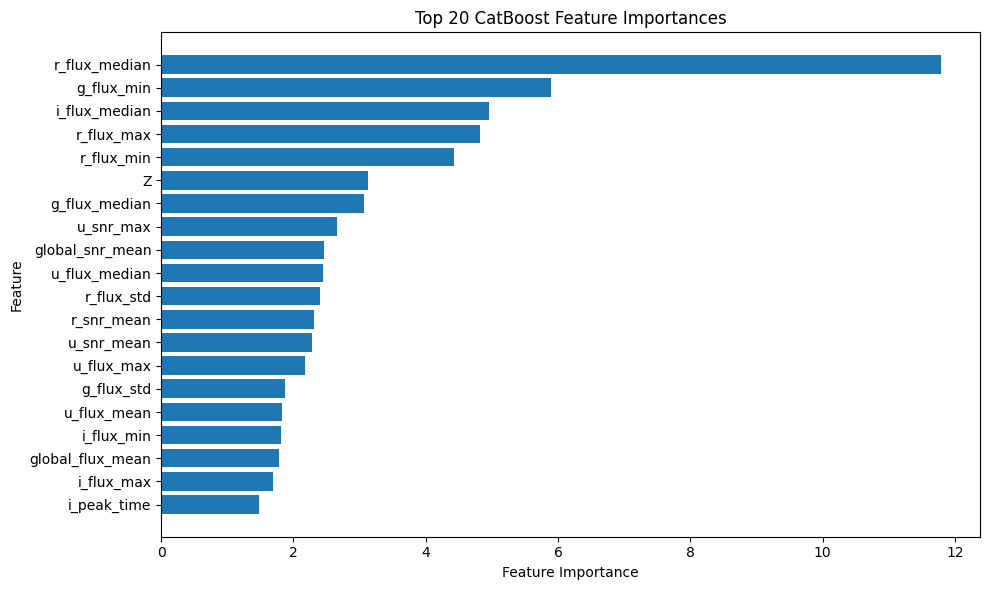

In [34]:

import matplotlib.pyplot as plt

# Get feature importances from the trained final model
importances = final_model.get_feature_importance()

# If X is a pandas DataFrame, use its column names
feature_names = X.columns

# Build DataFrame
feat_imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Sort descending and keep top 20
top20_feat_imp = feat_imp_df.sort_values(by="importance", ascending=False).head(20)

# Display table
print(top20_feat_imp)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top20_feat_imp["feature"][::-1], top20_feat_imp["importance"][::-1])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 CatBoost Feature Importances")
plt.tight_layout()
plt.show()

In [45]:
'''
Create the final Kaggle submission .csv file. Predict using the testing dataset
'''

test_probs = final_model.predict_proba(X_test)[:, 1]

test_preds = (test_probs >= best_threshold).astype(int)

# Build submission dataframe
submission = pd.DataFrame({
    "object_id": test_features["object_id"],
    "prediction": test_preds
})

# Save file
submission.to_csv("submission_dylan_hammond.csv", index=False)

print("Submission saved.")
print(submission.head())

Submission saved.
                      object_id  prediction
0      Eluwaith_Mithrim_nothrim           0
1            Eru_heledir_archam           0
2             Gonhir_anann_fuin           0
3  Gwathuirim_haradrim_tegilbor           0
4              achas_minai_maen           0
